In [1]:
%matplotlib inline
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

import config
from src.features import (
    build_aggregation_features,
    add_missingness_features,
    add_transformations,
    encode_categoricals,
)
from src.graph import build_entity_graph, get_graph_features

In [2]:
df = pd.read_parquet(config.RESULTS_PATH / 'data_clean.parquet')
orig_cols = set(df.columns)
print(df.shape)

(590540, 362)


## missingness features

Currently this adds 'has_identity' derived from DeviceType.notna()

In [3]:
df = add_missingness_features(df)
print(df.shape)
print(df['has_identity'].value_counts())
print(df.groupby('has_identity')[config.TARGET].mean())

(590540, 363)
has_identity
0    449730
1    140810
Name: count, dtype: int64
has_identity
0    0.021017
1    0.079618
Name: isFraud, dtype: float64


## aggregation features

In [4]:
shape_before = df.shape
cols_before_agg = set(df.columns)
df = build_aggregation_features(df)
agg_cols = [c for c in df.columns if c not in cols_before_agg]

print(f'before: {shape_before}')
print(f'after:  {df.shape}')
print(f'new columns ({len(agg_cols)}): {agg_cols}')

df[agg_cols[:5]].head()

before: (590540, 363)
after:  (590540, 384)
new columns (21): ['card1__addr1__nunique', 'card1__P_emaildomain__nunique', 'card1__R_emaildomain__nunique', 'card1__TransactionAmt__mean', 'card1__TransactionAmt__std', 'card1__TransactionID__count', 'P_emaildomain__card1__nunique', 'P_emaildomain__addr1__nunique', 'P_emaildomain__R_emaildomain__nunique', 'P_emaildomain__TransactionAmt__mean', 'R_emaildomain__card1__nunique', 'R_emaildomain__addr1__nunique', 'R_emaildomain__P_emaildomain__nunique', 'R_emaildomain__TransactionAmt__mean', 'addr1__card1__nunique', 'addr1__P_emaildomain__nunique', 'addr1__R_emaildomain__nunique', 'addr1__TransactionAmt__mean', 'DeviceInfo__card1__nunique', 'DeviceInfo__P_emaildomain__nunique', 'DeviceInfo__addr1__nunique']


,card1__addr1__nunique,card1__P_emaildomain__nunique,card1__R_emaildomain__nunique,card1__TransactionAmt__mean,card1__TransactionAmt__std
0,11,12,5,351.931163,371.141254
1,43,26,7,234.292753,460.356975
2,44,15,3,97.015542,100.128858
3,34,27,15,123.416340,192.717425
4,7,5,1,96.972222,56.629451


## log transformations

new columns (22): ['TransactionAmt_log', 'card1__addr1__nunique_log', 'card1__P_emaildomain__nunique_log', 'card1__R_emaildomain__nunique_log', 'card1__TransactionAmt__mean_log', 'card1__TransactionAmt__std_log', 'card1__TransactionID__count_log', 'P_emaildomain__card1__nunique_log', 'P_emaildomain__addr1__nunique_log', 'P_emaildomain__R_emaildomain__nunique_log', 'P_emaildomain__TransactionAmt__mean_log', 'R_emaildomain__card1__nunique_log', 'R_emaildomain__addr1__nunique_log', 'R_emaildomain__P_emaildomain__nunique_log', 'R_emaildomain__TransactionAmt__mean_log', 'addr1__card1__nunique_log', 'addr1__P_emaildomain__nunique_log', 'addr1__R_emaildomain__nunique_log', 'addr1__TransactionAmt__mean_log', 'DeviceInfo__card1__nunique_log', 'DeviceInfo__P_emaildomain__nunique_log', 'DeviceInfo__addr1__nunique_log']
(590540, 406)


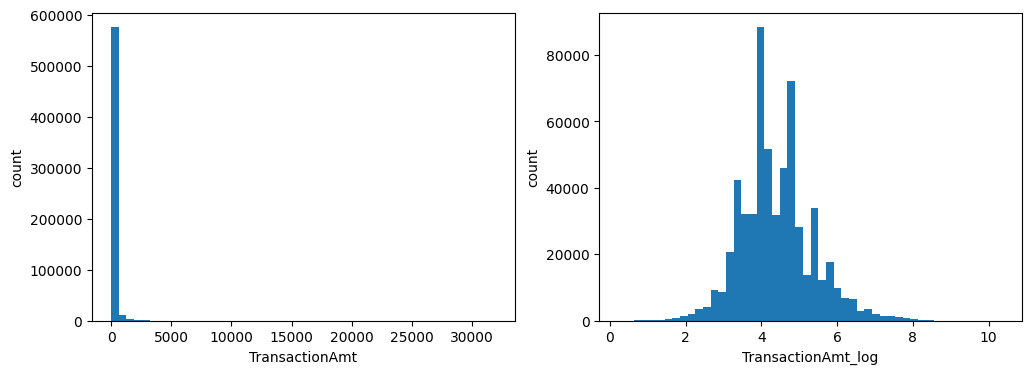

In [5]:
cols_before_log = set(df.columns)
df = add_transformations(df)
log_cols = [c for c in df.columns if c not in cols_before_log]
print(f'new columns ({len(log_cols)}): {log_cols}')

print(df.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['TransactionAmt'].dropna(), bins=50)
axes[0].set_xlabel('TransactionAmt')
axes[0].set_ylabel('count')
axes[1].hist(df['TransactionAmt_log'].dropna(), bins=50)
axes[1].set_xlabel('TransactionAmt_log')
axes[1].set_ylabel('count')
plt.savefig(str(config.PLOTS_PATH / 'log_transform_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## categorical encoding

In [6]:
cat_cols = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'DeviceType', 'DeviceInfo',
    'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28',
    'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35',
    'id_36', 'id_37', 'id_38',
]
# limit to columns present after null-column dropping
cat_cols = [c for c in cat_cols if c in df.columns]

cols_before_enc = set(df.columns)
df = encode_categoricals(df, cat_cols)
enc_cols = [c for c in df.columns if c not in cols_before_enc]
print(f'new columns ({len(enc_cols)}): {enc_cols}')

print(df[['card4', 'card4_encoded']].drop_duplicates().sort_values('card4').to_string(index=False))
print(df[['P_emaildomain', 'P_emaildomain_encoded']].drop_duplicates().sort_values('P_emaildomain').head(10).to_string(index=False))

new columns (26): ['ProductCD_encoded', 'card4_encoded', 'card6_encoded', 'P_emaildomain_encoded', 'R_emaildomain_encoded', 'M1_encoded', 'M2_encoded', 'M3_encoded', 'M4_encoded', 'M5_encoded', 'M6_encoded', 'M7_encoded', 'M8_encoded', 'M9_encoded', 'DeviceType_encoded', 'DeviceInfo_encoded', 'id_12_encoded', 'id_15_encoded', 'id_16_encoded', 'id_28_encoded', 'id_29_encoded', 'id_31_encoded', 'id_35_encoded', 'id_36_encoded', 'id_37_encoded', 'id_38_encoded']
           card4  card4_encoded
american express              0
        discover              1
      mastercard              2
            visa              4
             NaN              3
  P_emaildomain  P_emaildomain_encoded
        aim.com                      0
  anonymous.com                      1
        aol.com                      2
        att.net                      3
  bellsouth.net                      4
   cableone.net                      5
centurylink.net                      6
     cfl.rr.com                 

## graph features

In [7]:
entity_cols = [
    'card1', 'card2',
    'P_emaildomain', 'R_emaildomain',
    'addr1', 'addr2',
    'DeviceInfo'
]

G = build_entity_graph(df)
print(f'nodes: {G.number_of_nodes()}')
print(f'edges: {G.number_of_edges()}')

nodes: 15970
edges: 166644


In [8]:
shape_before_graph = df.shape
cols_before_graph = set(df.columns)
df = get_graph_features(G, df, entity_cols)
graph_cols = [c for c in df.columns if c not in cols_before_graph]

print(f'before: {shape_before_graph}')
print(f'after:  {df.shape}')
print(f'new columns ({len(graph_cols)}): {graph_cols}')

before: (590540, 432)
after:  (590540, 460)
new columns (28): ['card1_pagerank', 'card1_pagerank_weighted', 'card1_degree', 'card1_component_size', 'card2_pagerank', 'card2_pagerank_weighted', 'card2_degree', 'card2_component_size', 'P_emaildomain_pagerank', 'P_emaildomain_pagerank_weighted', 'P_emaildomain_degree', 'P_emaildomain_component_size', 'R_emaildomain_pagerank', 'R_emaildomain_pagerank_weighted', 'R_emaildomain_degree', 'R_emaildomain_component_size', 'addr1_pagerank', 'addr1_pagerank_weighted', 'addr1_degree', 'addr1_component_size', 'addr2_pagerank', 'addr2_pagerank_weighted', 'addr2_degree', 'addr2_component_size', 'DeviceInfo_pagerank', 'DeviceInfo_pagerank_weighted', 'DeviceInfo_degree', 'DeviceInfo_component_size']


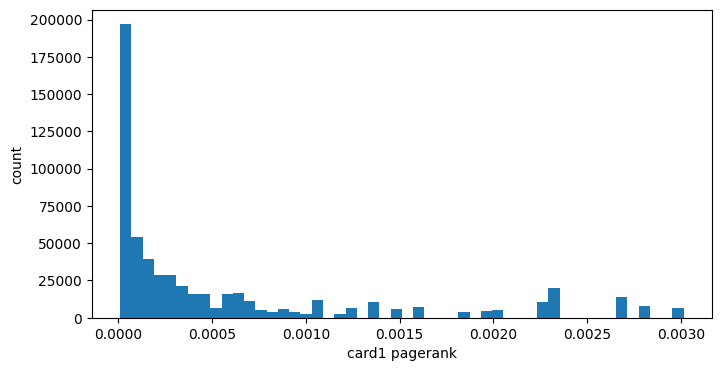

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['card1_pagerank'].dropna(), bins=50)
ax.set_xlabel('card1 pagerank')
ax.set_ylabel('count')
plt.savefig(str(config.PLOTS_PATH / 'card1_pagerank_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## save

In [10]:
new_feature_cols = [c for c in df.columns if c not in orig_cols]
df_features = df[['TransactionID'] + new_feature_cols]

df_features.to_parquet(config.RESULTS_PATH / 'features.parquet', index=False)
df.to_parquet(config.RESULTS_PATH / 'data_features.parquet', index=False)

print(f'data_clean:     ({df.shape[0]}, {len(orig_cols)})')
print(f'features:       {df_features.shape}')
print(f'data_features:  {df.shape}')

data_clean:     (590540, 362)
features:       (590540, 99)
data_features:  (590540, 460)


# Visualize fraud-heavy subgraph

top fraud hub node: gmail.com
fraud rate: 0.119
degree: 11451
ego nodes: 1083
ego edges: 4392


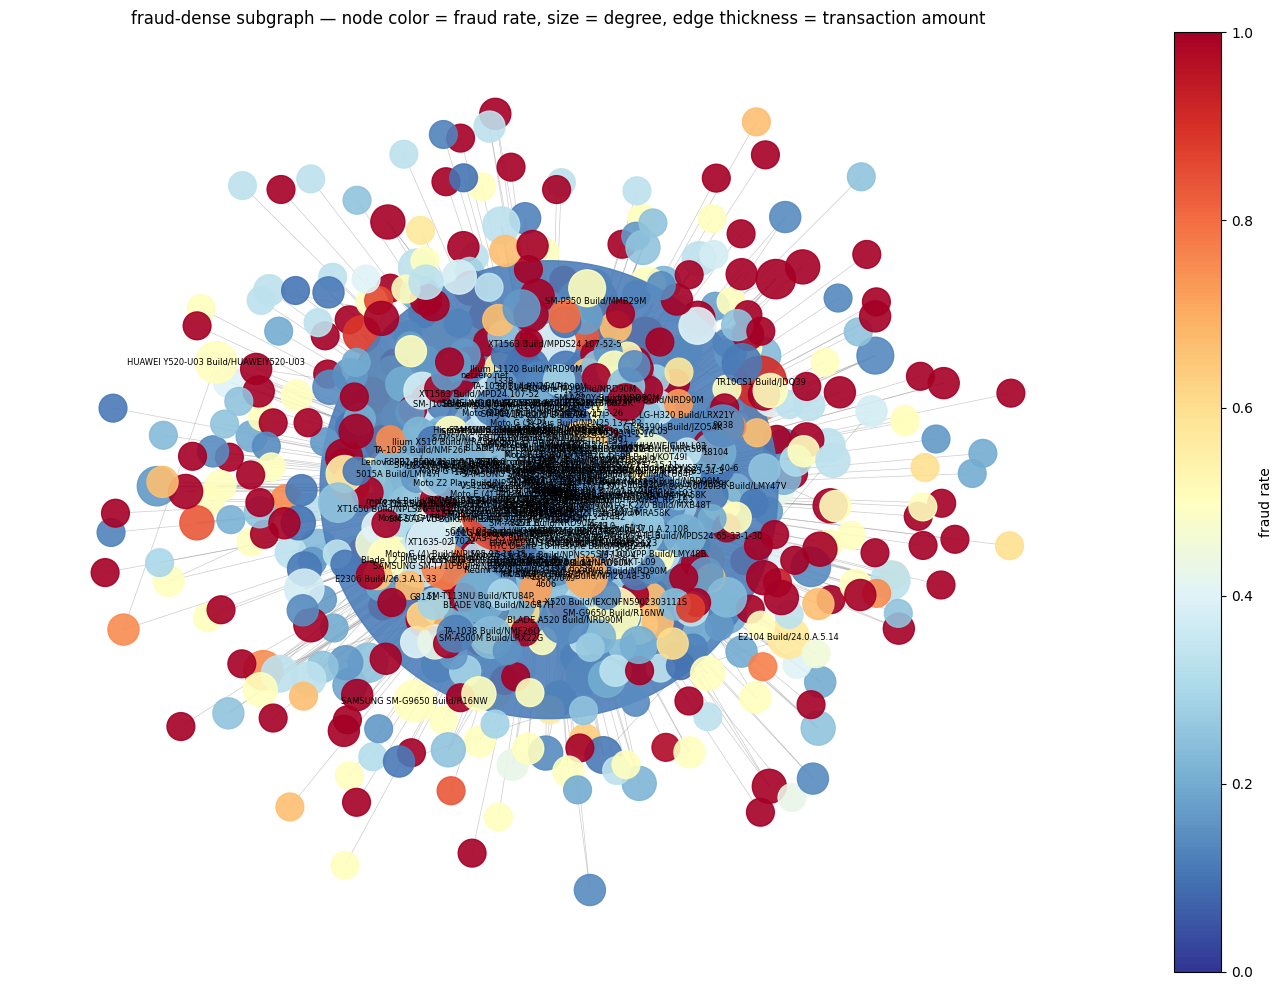

In [11]:
import networkx as nx
from src.graph import plot_fraud_subgraph

# build node fraud rate lookup
node_fraud_rates = {}
for col in entity_cols:
    rates = df.groupby(col)['isFraud'].mean().to_dict()
    node_fraud_rates.update(rates)

# find most connected node among nodes with fraud rate > 0.1
fraud_threshold = 0.1
candidate_nodes = {
    n for n in G.nodes
    if node_fraud_rates.get(n, 0) >= fraud_threshold
}

# pick highest degree among candidates
top_node = max(candidate_nodes, key=lambda n: G.degree(n))
print(f'top fraud hub node: {top_node}')
print(f'fraud rate: {node_fraud_rates.get(top_node, 0):.3f}')
print(f'degree: {G.degree(top_node)}')

# ego graph radius=1
ego = nx.ego_graph(G, top_node, radius=1)

# filter neighbors to fraud rate > threshold
high_fraud_nodes = {
    n for n in ego.nodes
    if node_fraud_rates.get(n, 0) >= fraud_threshold
}
high_fraud_nodes.add(top_node)
ego_filtered = ego.subgraph(high_fraud_nodes)

print(f'ego nodes: {ego_filtered.number_of_nodes()}')
print(f'ego edges: {ego_filtered.number_of_edges()}')

plot_fraud_subgraph(
    ego_filtered,
    node_fraud_rates,
    output_path=config.PLOTS_PATH / 'fraud_dense_subgraph.png'
)